# DecPyMC-11 — Valeur de l'Information en Souscription

**Série** : Théorie de la Décision, jambe actuarielle (EPIC #12904, tranche T5) — suite directe de
[DecPyMC-9](DecPyMC-9-Prime-Pure-Chargement.ipynb) (T1 : du risque à la prime) et
[DecPyMC-10](DecPyMC-10-Ruine-Lundberg.ipynb) (T4 : ruine et capital).

Le fil rouge continue. En T1 nous avons vu l'**antisélection** détruire un portefeuille tarifé au
prix moyen : les bons risques quittent le pool, les mauvais y restent. En T4 nous avons vu le
**prix de l'ignorance** : provisionner à la moyenne du posterior ignore la moitié droite de la
distribution. Ce notebook traite la question qui précède les deux autres : *avant* de tarifer,
*avant* de provisionner — **l'assureur peut-il acheter de l'information sur ses candidats, et
combien vaut-elle ?**

Un questionnaire médical, un examen complet, un boîtier télématique : chacun coûte de l'argent et
chacun renseigne — imparfaitement — sur le type du candidat. La **valeur de l'information**
(EVPI, EVSI — l'appareil de [DecPyMC-5](DecPyMC-5-Value-Information.ipynb)) donne le cadre exact
pour décider si le signal vaut son prix. Et la théorie des jeux regarde la même question par
l'autre bout : chez Spence (GT-17b), c'est *l'assuré* qui paie un signal coûteux pour se signaler
comme bon risque. Miroir marché / miroir assureur.

## Objectifs d'apprentissage

1. Poser la **décision de souscription** (accepter / refuser un candidat) comme un problème de
   décision sous incertitude, avec un seuil d'acceptation dérivable à la main.
2. Calculer l'**EVPI** de la classification parfaite des risques — le plafond de toute dépense
   d'information.
3. Calculer l'**EVSI** de trois signaux imparfaits (questionnaire, examen médical, télématique)
   et confronter chacun à son coût : la décision d'achat est un chiffre, pas une intuition.
4. Voir qu'un signal **corrélé au risque peut avoir une EVSI nulle** : seule l'information qui
   change la *décision* a de la valeur.
5. Propager l'**incertitude de calibration** du signal (PyMC) : l'EVSI elle-même devient une
   distribution — la décision d'achat peut être robuste ou en zone grise.
6. Construire le **miroir de Spence** : quand c'est l'assuré qui paie le signal, l'équilibre
   séparateur émerge — le lien explicite avec GT-17b.
7. Comparer **signal et expérience** : combien d'années sans sinistre valent un examen médical ?

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

# Supprime cet avertissement pytensor : son chemin site-packages (absolu) fuit un chemin machine
# dans une sortie commitee (classe #14200, Stop & Repair). Le message est benin, il ne change rien.
warnings.filterwarnings("ignore", message="Loop fusion failed because the resulting node would exceed the kernel argument limit")

rng = np.random.default_rng(20260825)
plt.rcParams["figure.dpi"] = 110
print("imports OK — pymc", pm.__version__)

g++ not available, if using conda: `conda install gxx`


imports OK — pymc 6.3.1


***
## 1. La décision de souscription sans information

Rappel du fil rouge T1/T4, à l'échelle d'une **police individuelle** (primes de l'ordre de
quelques milliers d'euros — typique d'une assurance emprunteur ou professionnelle, ce qui rend
les coûts de souscription visibles devant les primes) :

- deux types de candidats : **bon risque** (fréquence de sinistre $\lambda_g = 0{,}03$/an) et
  **mauvais risque** ($\lambda_b = 0{,}09$/an), coût moyen d'un sinistre $E[S] = 50\,000$ € ;
- prime pure : $\pi_g = \lambda_g E[S] = 1\,500$ €, $\pi_b = \lambda_b E[S] = 4\,500$ € ;
- dans la population des candidats : 30 % de mauvais risques — mais **l'assureur ne voit pas le
  type**, seulement le mélange : $\pi_{\text{pool}} = 2\,400$ € ;
- prime commerciale au pool avec chargement $\theta = 10\,\%$ : $P = 2\,640$ €.

La décision de l'assureur pour chaque candidat : **accepter** (résultat $= P - \pi_{\text{type}}$)
ou **refuser** (résultat $= 0$). Définissons ces quantités et dérivons la règle optimale sans
information :

In [2]:
# Parametres du fil rouge (echelle police individuelle)
LAMBDA_G, LAMBDA_B = 0.03, 0.09          # frequences annuelles de sinistre (bon / mauvais)
E_S = 50_000.0                            # cout moyen d'un sinistre (EUR)
P_MAUVAIS = 0.30                          # proportion de mauvais risques parmi les candidats
THETA = 0.10                              # chargement

PI_G, PI_B = LAMBDA_G * E_S, LAMBDA_B * E_S
PI_POOL = P_MAUVAIS * PI_B + (1 - P_MAUVAIS) * PI_G
PRIME = PI_POOL * (1 + THETA)             # prime commerciale au pool

PROFIT_G = PRIME - PI_G                   # resultat si le candidat accepte est bon risque
PROFIT_B = PRIME - PI_B                   # ... s'il est mauvais risque (negatif)

baseline = P_MAUVAIS * PROFIT_B + (1 - P_MAUVAIS) * PROFIT_G   # esperance accepter-tous

# Seuil d'acceptation : accepter est optimal ssi E[profit | p] = p*PROFIT_B + (1-p)*PROFIT_G > 0
SEUIL = PROFIT_G / (PROFIT_G - PROFIT_B)  # = 0.38 : accepter ssi P(mauvais | info) < SEUIL

print(f"prime pure : pi_g = {PI_G:.0f} EUR | pi_b = {PI_B:.0f} EUR | pool = {PI_POOL:.0f} EUR")
print(f"prime commerciale au pool : P = {PRIME:.0f} EUR (chargement {THETA:.0%})")
print(f"profit par police acceptee : bon risque +{PROFIT_G:.0f} EUR | mauvais risque {PROFIT_B:.0f} EUR")
print(f"regle optimale sans info : accepter tous -> E[profit] = {baseline:.0f} EUR par candidat")
print(f"seuil de refus : P(mauvais | information) > {SEUIL:.3f}")

prime pure : pi_g = 1500 EUR | pi_b = 4500 EUR | pool = 2400 EUR
prime commerciale au pool : P = 2640 EUR (chargement 10%)
profit par police acceptee : bon risque +1140 EUR | mauvais risque -1860 EUR
regle optimale sans info : accepter tous -> E[profit] = 240 EUR par candidat
seuil de refus : P(mauvais | information) > 0.380


### Interprétation

Trois chiffres structurent tout le notebook. (1) Accepter tout le monde au tarif pool rapporte en
espérance **+240 € par candidat** — le chargement de 10 % paie le mélange. (2) Mais ce profit est
une moyenne écrasée : chaque mauvais risque accepté **coûte 1 860 €**, chaque bon risque en
rapporte 1 140. (3) La règle optimale face à une *probabilité* $p$ que le candidat soit mauvais
risque est triviale à dériver : accepter ssi $p < 0{,}38$ — le **seuil de refus**. Toute
l'information du monde ne sert qu'à déplacer $p$ de part et d'autre de ce seuil ; c'est la clé de
la suite. (Et souvenez-vous de T1 : si l'assureur ne peut refuser personne et tarife au pool, les
bons risques partent chez le concurrent qui, lui, les identifie — l'antisélection travaille
sous vos pieds pendant que vous calculez.)

***
## 2. EVPI : le plafond de la classification parfaite

Supposons l'information **parfaite** : l'assureur connaît le type de chaque candidat. La règle
optimale devient triviale — refuser les mauvais risques (perte certaine de 1 860 €), accepter les
bons (+1 140 €). La **valeur de l'information parfaite** (EVPI) est le gain d'espérance :

$$\text{EVPI} = \mathbb{E}[\text{profit} \mid \text{info parfaite}] - \mathbb{E}[\text{profit} \mid \text{aucune info}]$$

C'est le **plafond absolu** : aucune dépense d'information — questionnaire, examen, data — ne peut
valoir plus que l'EVPI par candidat.

In [3]:
# EVPI : on refuse les mauvais risques, on accepte les bons
esperance_parfaite = (1 - P_MAUVAIS) * max(PROFIT_G, 0.0) + P_MAUVAIS * max(PROFIT_B, 0.0)
evpi = esperance_parfaite - baseline
print(f"E[profit | info parfaite] = {esperance_parfaite:.0f} EUR par candidat")
print(f"E[profit | aucune info]   = {baseline:.0f} EUR par candidat")
print(f"EVPI = {evpi:.0f} EUR par candidat  (plafond de toute depense d'information)")

E[profit | info parfaite] = 798 EUR par candidat
E[profit | aucune info]   = 240 EUR par candidat
EVPI = 558 EUR par candidat  (plafond de toute depense d'information)


### Interprétation

L'EVPI vaut **558 € par candidat** : c'est exactement la part des mauvais risques (30 %) que
l'assureur cesse d'absorber, soit $0{,}30 \times 1\,860$. Aucun signal, aussi bon soit-il, ne peut
rapporter davantage — un signal parfait *est* ce chiffre. Notons l'ordre de grandeur : tout
processus de sélection qui coûterait plus de 558 € par candidat est condamné d'avance, même s'il
est exact à 100 %. La question devient : à quelle *fraction* de ce plafond chaque signal
imparfait accède-t-il, et pour quel coût ?

### Exercice 1 : EVPI et structure du portefeuille

L'EVPI dépend de la proportion de mauvais risques $p$. Complétez la fonction `evpi_p(p)` et la
grille ci-dessous : pour $p \in \{0{,}1,\ 0{,}2,\ 0{,}3,\ 0{,}5,\ 0{,}7\}$, calculez l'EVPI.
Vérifiez votre intuition : que vaut l'EVPI à $p = 0$ et à $p = 1$ ? Pour quel $p$ intermédiaire
est-elle maximale ? *Indice : sans information, la règle « accepter tous » n'est plus optimale
quand $p$ dépasse le seuil 0.38 — que devient alors la référence « aucune info » ?*

In [4]:
# Exercice 1 : a completer
def evpi_p(p_mauvais):
    """EVSI d'une information PARFAITE pour une proportion p_mauvais de mauvais risques."""
    pass  # TODO etudiant : (1) profit bons/mauvais au tarif pool, (2) regle optimale SANS info
           #            (accepter tous, ou refuser tous selon le signe de l'esperance),
           #            (3) regle AVEC info parfaite, (4) difference.

resultats_ex1 = None  # TODO etudiant : dict {p: evpi} pour p dans [0.1, 0.2, 0.3, 0.5, 0.7]
print("Exercice 1 a completer")
print("  resultats :", resultats_ex1)

Exercice 1 a completer
  resultats : None


***
## 3. Trois signaux imparfaits : Bayes à la main

L'information parfaite n'existe pas ; ce qui existe, ce sont des **signaux** — chacun décrit par
sa **sensibilité** (probabilité d'alerter sur un mauvais risque) et sa **spécificité** (probabilité
de ne pas alerter sur un bon risque), et son **coût** par candidat :

| Signal | Sensibilité | Spécificité | Coût / candidat |
|---|---|---|---|
| Questionnaire médical (déclaratif) | 0,40 | 0,65 | 15 € |
| Examen médical complet | 0,70 | 0,90 | 90 € |
| Télématique (analyse d'un an de conduite) | 0,90 | 0,97 | 500 € |

Le théorème de Bayes transforme le signal en posterior — c'est *l'application actuarielle* du
cours de DecPyMC-5. Pour un signal positif : $P(\text{mauvais} \mid +) = \frac{p \cdot \text{sens}}{p \cdot \text{sens} + (1-p)(1-\text{spec})}$.
Le tableau complet :

In [5]:
SIGNAUX = {
    "questionnaire": dict(sens=0.40, spec=0.65, cout=15.0),
    "examen":        dict(sens=0.70, spec=0.90, cout=90.0),
    "telematique":   dict(sens=0.90, spec=0.97, cout=500.0),
}

lignes = []
for nom, s in SIGNAUX.items():
    p_pos = P_MAUVAIS * s["sens"] + (1 - P_MAUVAIS) * (1 - s["spec"])
    p_neg = 1 - p_pos
    p_bad_pos = P_MAUVAIS * s["sens"] / p_pos
    p_bad_neg = P_MAUVAIS * (1 - s["sens"]) / p_neg
    e_pos = max(p_bad_pos * PROFIT_B + (1 - p_bad_pos) * PROFIT_G, 0.0)
    e_neg = max(p_bad_neg * PROFIT_B + (1 - p_bad_neg) * PROFIT_G, 0.0)
    lignes.append(dict(signal=nom, P_pos=p_pos, P_bad_pos=p_bad_pos, P_bad_neg=p_bad_neg,
                       action_pos="refuser" if p_bad_pos > SEUIL else "accepter",
                       action_neg="refuser" if p_bad_neg > SEUIL else "accepter",
                       E_profit=p_pos * e_pos + p_neg * e_neg))
tbl_bayes = pd.DataFrame(lignes).round(3)
print(tbl_bayes.to_string(index=False))
print(f"\nreference sans information : E[profit] = {baseline:.0f} EUR (seuil de refus = {SEUIL:.2f})")

       signal  P_pos  P_bad_pos  P_bad_neg action_pos action_neg  E_profit
questionnaire  0.365      0.329      0.283   accepter   accepter    240.00
       examen  0.280      0.750      0.125    refuser   accepter    550.80
  telematique  0.291      0.928      0.042    refuser   accepter    718.26



reference sans information : E[profit] = 240 EUR (seuil de refus = 0.38)


### Interprétation

Lisez la colonne `P_bad_pos` contre le seuil 0.38 — c'est là que tout se joue. L'**examen médical**
et la **télématique** franchissent le seuil dans les deux sens : signal positif → refus (0.75 et
0.93 de mauvais risque), signal négatif → acceptation (0.13 et 0.04). Ils *changent la décision*.
Le **questionnaire**, lui, reste sous le seuil dans les deux branches (0.33 / 0.28) : même un
signal positif ne suffit pas à refuser le candidat. Le signal bouge la croyance mais pas l'action —
et un signal qui ne change pas l'action ne peut pas changer le résultat. C'est la leçon centrale
de l'EVSI, plus forte que sa version intuitive « plus d'info = mieux » : **la valeur d'un signal
se mesure en décisions changées, pas en corrélations**.

***
## 4. EVSI : la valeur de chaque signal contre son coût

L'**espérance de valeur d'information imparfaite** (EVSI) est la différence entre le profit
espéré avec la règle bayésienne optimale après le signal et le profit sans information :

$$\text{EVSI} = \sum_{s \in \{+,-\}} P(s) \cdot \max\big(\mathbb{E}[\text{profit} \mid s, \text{accepter}],\ 0\big) - \text{baseline}$$

La **décision d'achat** du signal est alors un simple ligne à ligne : EVSI nette = EVSI − coût.
Calculons pour les trois signaux et confrontons au plafond EVPI :

       signal  EVSI  cout  EVSI_nette  part_EVPI
questionnaire   0.0  15.0       -15.0        0.0
       examen 310.8  90.0       220.8       55.7
  telematique 478.3 500.0       -21.7       85.7

EVPI (plafond) = 558 EUR par candidat


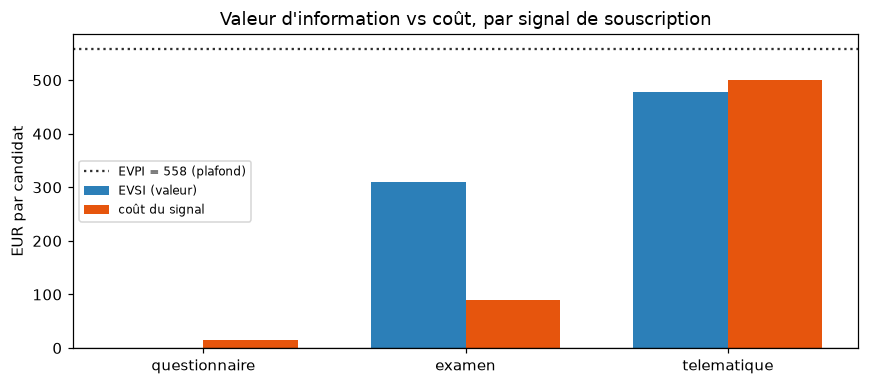

In [6]:
def evsi_signal(sens, spec, p_bad=P_MAUVAIS, profit_g=PROFIT_G, profit_b=PROFIT_B):
    """EVSI d'un signal binaire (sens, spec) — vectorisable (tableaux numpy OK)."""
    p_pos = p_bad * sens + (1 - p_bad) * (1 - spec)
    p_pos = np.clip(p_pos, 1e-12, 1.0)
    p_bad_pos = p_bad * sens / p_pos
    p_bad_neg = p_bad * (1 - sens) / (1 - p_pos)
    e_pos = np.maximum(p_bad_pos * profit_b + (1 - p_bad_pos) * profit_g, 0.0)
    e_neg = np.maximum(p_bad_neg * profit_b + (1 - p_bad_neg) * profit_g, 0.0)
    return p_pos * e_pos + (1 - p_pos) * e_neg - (p_bad * profit_b + (1 - p_bad) * profit_g)

lignes = []
for nom, s in SIGNAUX.items():
    v = evsi_signal(s["sens"], s["spec"])
    lignes.append(dict(signal=nom, EVSI=v, cout=s["cout"], EVSI_nette=v - s["cout"],
                       part_EVPI=100 * v / evpi))
tbl_evsi = pd.DataFrame(lignes).round(1)
print(tbl_evsi.to_string(index=False))
print(f"\nEVPI (plafond) = {evpi:.0f} EUR par candidat")

fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(tbl_evsi))
ax.bar(x - 0.18, tbl_evsi["EVSI"], width=0.36, label="EVSI (valeur)", color="#2C7FB8")
ax.bar(x + 0.18, tbl_evsi["cout"], width=0.36, label="coût du signal", color="#E6550D")
ax.axhline(evpi, color="#2F2F2F", ls=":", lw=1.5, label=f"EVPI = {evpi:.0f} (plafond)")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x, tbl_evsi["signal"])
ax.set_ylabel("EUR par candidat")
ax.set_title("Valeur d'information vs coût, par signal de souscription")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Interprétation

La décision d'achat, chiffrée : le **questionnaire** rapporte une EVSI quasi nulle (le signal ne
change aucune décision, section 3) mais coûte 15 € — **net négatif, on ne l'achète pas**. L'**
examen médical** capte 310 € de valeur (56 % du plafond EVPI) pour 90 € — **net +221 €, on
l'achète**. La **télématique** est le meilleur signal en qualité (86 % du plafond) mais son coût
de 500 € l'emporte sur ses 478 € d'EVSI — **net marginal négatif, on ne l'achète pas** en
souscription une-shot. Notez la forme du problème : le classement des signaux par *qualité
bayésienne* (télématique > examen > questionnaire) n'est PAS le classement par *valeur nette*
(examen > télématique > questionnaire). La meilleure information n'est pas la plus exacte —
c'est celle dont la précision marginale paie encore son coût.

### Exercice 2 : évaluer un nouveau signal

Un fournisseur propose un **score de risque basé sur les données ouvertes** (âge du permis,
puissance du véhicule, zone géographique) : sensibilité 0.55, spécificité 0.80, coût 60 € par
candidat. Complétez le calcul de son EVSI nette avec `evsi_signal`, et déterminez : (1) le signal
change-t-il des décisions aux deux issues (vérifiez les posteriors contre le seuil) ? (2) Quelle
sensibilité minimale, à spécificité 0.80 et coût 60 € fixés, rendrait-il l'achat net positif ?

In [7]:
# Exercice 2 : a completer
evsi_score = None   # TODO etudiant : evsi_signal(0.55, 0.80) puis moins le cout 60 EUR
print("Exercice 2 a completer")
print(f"  EVSI nette du score open-data : {evsi_score} EUR")

Exercice 2 a completer
  EVSI nette du score open-data : None EUR


***
## 5. Validation Monte Carlo

L'EVSI est une espérance calculée sur deux issues — vérifions-la en simulant des candidats
réels : 20 000 candidats, types et signaux tirés selon le modèle, règles appliquées, profits
réalisés. C'est aussi l'occasion de voir ce que les distributions font derrière les moyennes —
car un assureur ne vit pas d'espérances, il vit de trajectoires :

               moyenne  ecart_type  part_refuse  perte_P5
sans info        249.6      1370.5          0.0   -1860.0
questionnaire    235.0      1376.9          0.0   -1860.0
examen           553.5       912.8         27.5   -1860.0
telematique      723.6       674.0         29.3       0.0


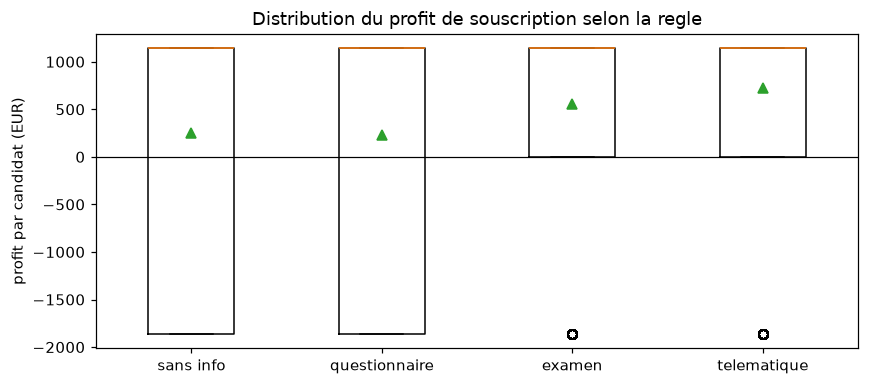

In [8]:
N_CAND = 20_000

def simuler_portefeuille(sens=None, spec=None, n=N_CAND, seed=7):
    """Simule n candidats ; regle : accepter ssi P(mauvais | signal) < SEUIL (ou tous si pas de signal)."""
    r = np.random.default_rng(seed)
    types = r.binomial(1, P_MAUVAIS, n)                      # 1 = mauvais risque
    if sens is None:
        accepte = np.ones(n, dtype=bool)
    else:
        alerte = (r.random(n) < np.where(types == 1, sens, 1 - spec))
        p_pos = P_MAUVAIS * sens + (1 - P_MAUVAIS) * (1 - spec)
        p_bad_pos = P_MAUVAIS * sens / p_pos
        p_bad_neg = P_MAUVAIS * (1 - sens) / (1 - p_pos)
        p_bad_post = np.where(alerte, p_bad_pos, p_bad_neg)
        accepte = p_bad_post < SEUIL
    profit = np.where(accepte, PROFIT_G - (PROFIT_G - PROFIT_B) * types, 0.0)
    return profit

regles = {"sans info": dict()}
for nom, s in SIGNAUX.items():
    regles[nom] = s
profits = {nom: simuler_portefeuille(s.get("sens"), s.get("spec"), seed=11 + i)
           for i, (nom, s) in enumerate(regles.items())}

stats = pd.DataFrame({nom: dict(moyenne=p.mean(), ecart_type=p.std(),
                                part_refuse=100 * (p == 0).mean(),
                                perte_P5=np.percentile(p, 5))
                      for nom, p in profits.items()}).T.round(1)
print(stats.to_string())

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.boxplot(list(profits.values()), tick_labels=list(profits.keys()), showmeans=True)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("profit par candidat (EUR)")
ax.set_title("Distribution du profit de souscription selon la regle")
plt.tight_layout(); plt.show()

### Interprétation

La simulation confirme les espérances analytiques (moyennes MC ≈ EVSI + baseline aux fluctuations
d'échantillonnage près) — mais le tableau montre ce que l'espérance cachait : **le tri des
candidats réduit la queue de pertes, sans la supprimer**. Sans information, 30 % des candidats
acceptés perdent 1 860 € chacun. Avec l'examen, les faux négatifs restent : ~9 % des candidats
sont des mauvais risques au signal négatif, acceptés à tort (d'où `perte_P5` = −1 860 € encore) ;
la télématique, plus précise, tombe à ~3 % — et son `perte_P5` passe à 0 €. Regardez aussi la
ligne `part_refuse` : le questionnaire refuse ~0 % des candidats (conforme : il ne change aucune
décision), l'examen ~28 %, la télématique ~29 % — et pourtant leurs valeurs nettes diffèrent du
tout au tout, parce que la télématique paie 500 € pour ce tri quand l'examen le paie 90 €.

***
## 6. L'EVSI est elle-même incertaine : calibration bayésienne (PyMC)

D'où viennent les sensibilité/spécificité de nos signaux ? D'une **étude de calibration** : on a
fait passer le questionnaire à 60 mauvais risques connus (24 alertes) et à 100 bons risques
connus (35 fausses alertes) ; l'examen médical à 100/100 (70 et 10). Les vraies sensibilité et
spécificité sont **estimées**, avec une incertitude qui se propage à l'EVSI — exactement le
mécanisme du prix de l'ignorance de T4, mais appliqué à la *qualité du signal* plutôt qu'au
risque. Modèle PyMC (Beta-Binomial, NUTS) :

In [9]:
with pm.Model() as modele_calibration:
    sens_q = pm.Beta("sens_q", alpha=2.0, beta=2.0)
    fpr_q = pm.Beta("fpr_q", alpha=2.0, beta=2.0)
    sens_m = pm.Beta("sens_m", alpha=2.0, beta=2.0)
    fpr_m = pm.Beta("fpr_m", alpha=2.0, beta=2.0)

    pm.Binomial("alertes_q_mauvais", n=60, p=sens_q, observed=24)
    pm.Binomial("fausses_q_bons", n=100, p=fpr_q, observed=35)
    pm.Binomial("alertes_m_mauvais", n=100, p=sens_m, observed=70)
    pm.Binomial("fausses_m_bons", n=100, p=fpr_m, observed=10)

    trace_calib = pm.sample(1_500, tune=1_500, chains=2, random_seed=20260825,
                            progressbar=False, return_inferencedata=True)

az.summary(trace_calib, round_to=3)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [sens_q, fpr_q, sens_m, fpr_m]


Sampling 2 chains for 1_500 tune and 1_500 draw iterations (3_000 + 3_000 draws total) took 7 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sens_q,0.406,0.061,0.307,0.506,4777.332,2600.155,1.000,0.001,0.001
fpr_q,0.355,0.047,0.283,0.431,4755.101,2446.818,1.000,0.001,0.000
sens_m,0.692,0.046,0.617,0.766,4308.970,2603.155,1.001,0.001,0.000
fpr_m,0.116,0.031,0.070,0.169,4437.837,2335.694,1.001,0.000,0.000


### Interprétation du posterior de calibration

L'examen médical est calibré serré : sensibilité ~0.70 ± 0.05, taux de faux positifs ~0.10 ±
0.03 — l'étude (100/100 observations) a fait son travail. Le questionnaire est **plus incertain**
(sensibilité ~0.40 avec un intervalle nettement plus large relativement, faux positifs ~0.35 ±
0.05) : 60 observations sur une question plus bruitée. Vérifiez `ess_bulk` et `r_hat` : les deux
doivent indiquer une convergence propre (r_hat ≈ 1.00) avant de propager — un posterior mal
échantillonné propagerait son artefact dans la décision d'achat. Propageons chaque tirage
posterior vers *sa* EVSI :

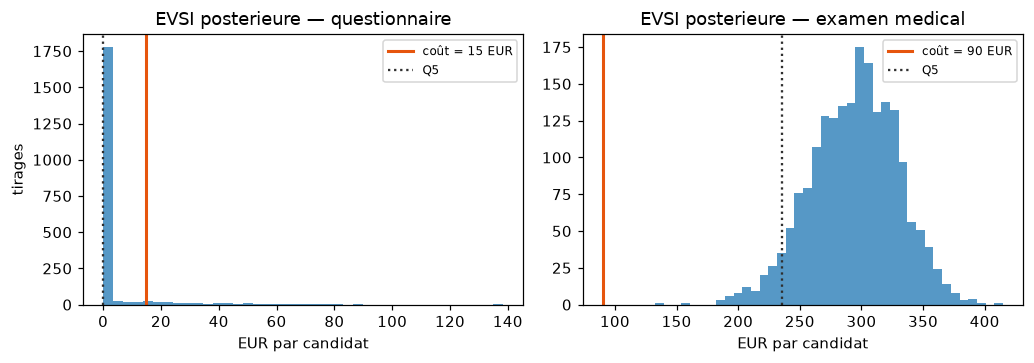

questionnaire  EVSI : Q5 =   -0.0 | mediane =    0.0 | Q95 =   25.8 | P(EVSI > cout) = 0.08
examen         EVSI : Q5 =  235.2 | mediane =  296.9 | Q95 =  350.9 | P(EVSI > cout) = 1.00


In [10]:
post = trace_calib.posterior
draws = np.stack([post["sens_q"].values.ravel(), post["fpr_q"].values.ravel(),
                  post["sens_m"].values.ravel(), post["fpr_m"].values.ravel()], axis=1)
idx = np.random.default_rng(20260825).choice(len(draws), size=2_000, replace=False)
evsi_q_draws = evsi_signal(draws[idx, 0], 1 - draws[idx, 1])          # questionnaire
evsi_m_draws = evsi_signal(draws[idx, 2], 1 - draws[idx, 3])          # examen

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.4), sharey=False)
for ax_i, (nom, d, cout) in zip(ax, [("questionnaire", evsi_q_draws, SIGNAUX["questionnaire"]["cout"]),
                                     ("examen medical", evsi_m_draws, SIGNAUX["examen"]["cout"])]):
    ax_i.hist(d, bins=40, color="#2C7FB8", alpha=0.8)
    ax_i.axvline(cout, color="#E6550D", lw=2, label=f"coût = {cout:.0f} EUR")
    ax_i.axvline(np.percentile(d, 5), color="#2F2F2F", ls=":", lw=1.5, label="Q5")
    ax_i.set_title(f"EVSI posterieure — {nom}")
    ax_i.set_xlabel("EUR par candidat")
    ax_i.legend(fontsize=8)
ax[0].set_ylabel("tirages")
plt.tight_layout(); plt.show()

for nom, d, cout in [("questionnaire", evsi_q_draws, 15.0), ("examen", evsi_m_draws, 90.0)]:
    print(f"{nom:14s} EVSI : Q5 = {np.percentile(d, 5):6.1f} | mediane = {np.median(d):6.1f} | "
          f"Q95 = {np.percentile(d, 95):6.1f} | P(EVSI > cout) = {(d > cout).mean():.2f}")

### Interprétation

La décision d'achat devient elle-même une **statistique bayésienne**. Pour l'**examen médical** :
toute la distribution postérieure de l'EVSI est au-dessus de son coût (P(EVSI > coût) ≈ 1) —
l'achat est **robuste** : même pessimiste sur la calibration, l'examen reste nettement rentable.
Pour le **questionnaire** : la médiane est à ~0 €, mais 8 % des mondes possibles (calibrations
meilleures que l'estimation) dépassent les 15 €, et le quantile 95 atteint 26 € — pas de quoi
acheter en confiance, pas de quoi jeter le signal non plus : la décision est en **zone grise**. La sagesse opérationnelle : en zone grise, la prochaine dépense utile n'est pas
d'acheter le signal, c'est d'**acheter de l'information sur le signal** (agrandir l'étude de
calibration) — la valeur d'information s'applique récursivement à elle-même. C'est aussi une
réponse au point EVSI ≈ 0 de la section 4 : ce n'est pas un verdict définitif, c'est une
estimation entourée d'incertitude, et le calcul dit laquelle.

***
## 7. Le miroir de Spence : qui paie le signal ?

Jusqu'ici l'assureur achetait l'information. La théorie des jeux (GT-17b, Rothschild–Stiglitz et
Spence) regarde la même situation par l'autre bout : **c'est l'assuré qui paie un signal coûteux**
pour se révéler bon risque. Passer la télématique coûte 500 € ; en échange, l'assureur tarife à la
prime du type révélé (prime pure + chargement) au lieu du pool. Calculons ce que chaque type
gagne à porter le boîtier :

In [11]:
tarif_g = PI_G * (1 + THETA)
tarif_b = PI_B * (1 + THETA)
cout_boitier = 500.0

economie_bon = PRIME - tarif_g            # ce que le bon risque economise en se revelant
surcout_mauvais = tarif_b - PRIME         # ce que le mauvais risque paierait de plus en se revelant

print(f"tarif au pool            : {PRIME:.0f} EUR/an")
print(f"tarif bon risque revele  : {tarif_g:.0f} EUR/an  -> economie nette du boitier : {economie_bon - cout_boitier:+.0f} EUR/an")
print(f"tarif mauvais risque     : {tarif_b:.0f} EUR/an  -> surcout du boitier         : {surcout_mauvais + cout_boitier:+.0f} EUR/an")
print(f"\ncout maximal du boitier separateur : c* = economie du bon risque = {economie_bon:.0f} EUR/an")
print("bon risque adopte le boitier ssi c* > cout ; le mauvais risque ne l'adopte jamais (il paierait")
print("le boitier ET son tarif juste : double penalite). Le boitier separe les types tout seul.")

tarif au pool            : 2640 EUR/an
tarif bon risque revele  : 1650 EUR/an  -> economie nette du boitier : +490 EUR/an
tarif mauvais risque     : 4950 EUR/an  -> surcout du boitier         : +2810 EUR/an

cout maximal du boitier separateur : c* = economie du bon risque = 990 EUR/an
bon risque adopte le boitier ssi c* > cout ; le mauvais risque ne l'adopte jamais (il paierait
le boitier ET son tarif juste : double penalite). Le boitier separe les types tout seul.


### Interprétation

Le boîtier télématique **sépare les types sans que l'assureur ne décide rien** : le bon risque
économise 990 €/an de prime en payant 500 € de boîtier (net +490 : il adopte), le mauvais risque
perdrait 2 310 € de prime plus le boîtier (il refuse). Un équilibre séparateur émerge — et il est
*plus fort* que le tri par l'assureur de la section 4 : la télématique en souscription avait une
EVSI nette négative pour l'assureur, mais **portée par l'assuré elle trie gratuitement** les
candidats à l'entrée. C'est exactement le théorème de Spence lu à l'envers : le signal coûteux
n'a pas besoin d'être *acheté* par celui qui valorise l'information, il suffit que son coût soit
**différentiel** entre types. La limite (Rothschild–Stiglitz, GT-17b) : une fois les bons risques
partis au tarif révélateur, le pool restant est 100 % mauvais risque et le tarif pool 2 640 €
devient intenable — l'assureur doit le monter à 4 950 €, et le pool disparaît. La séparation
complète n'est pas toujours un équilibre de marché viable ; c'est toute la littérature des
contrats d'assurance à l'équilibre, dont GT-17b donne la version complète.

### Exercice 3 : le coût séparateur maximal

Le fabricant du boîtier propose trois formules : Essential (400 €/an, sens 0.80 / spec 0.95),
Premium (500 €/an, 0.90 / 0.97) et Prestige (900 €/an, 0.95 / 0.98). (1) Vérifiez que le seuil
$c^* = 990$ €/an s'applique aux trois formules vues du côté de l'assuré : lesquelles les bons
risques adoptent-ils encore ? (2) Vu de l'assureur (souscription une-shot, section 4), calculez
l'EVSI nette des trois formules avec `evsi_signal` — le classement des deux points de vue
coïncide-t-il ?

In [12]:
# Exercice 3 : a completer
formules = {"Essential": (400.0, 0.80, 0.95), "Premium": (500.0, 0.90, 0.97), "Prestige": (900.0, 0.95, 0.98)}
adoption_bon_risque = None   # TODO etudiant : dict {formule: bool} — cote assure (c* = 990)
evsi_nette_assureur = None   # TODO etudiant : dict {formule: float} — cote assureur (evsi_signal - cout)
print("Exercice 3 a completer")
print("  adoption par le bon risque :", adoption_bon_risque)
print("  EVSI nette assureur         :", evsi_nette_assureur)

Exercice 3 a completer
  adoption par le bon risque : None
  EVSI nette assureur         : None


***
## 8. Expérience contre signal : le temps comme source d'information

Reste une dernière source d'information, gratuite celle-là : **le temps**. Chaque année sans
sinistre est une observation du type du candidat — le mécanisme exact du posterior de T1, appliqué
au renouvellement. La fréquence annuelle est faible (0.03 / 0.09), donc une année muette est une
preuve *faible*. Combien d'années faut-il pour apprendre ce que la télématique dit en un an ?

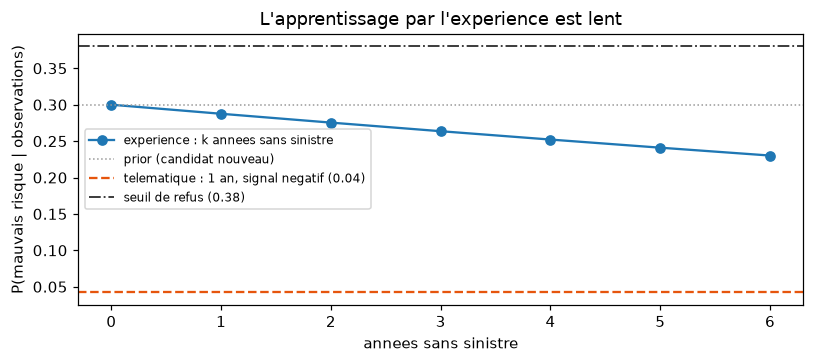

P(mauvais) apres k annees sans sinistre :
  k = 0 : 0.300
  k = 1 : 0.288
  k = 2 : 0.275
  k = 3 : 0.264
  k = 4 : 0.252
  k = 5 : 0.241
  k = 6 : 0.230


In [13]:
annees = np.arange(0, 7)
p_bad_experience = (P_MAUVAIS * np.exp(-LAMBDA_B * annees)
                    / (P_MAUVAIS * np.exp(-LAMBDA_B * annees)
                       + (1 - P_MAUVAIS) * np.exp(-LAMBDA_G * annees)))

p_pos_tel = P_MAUVAIS * SIGNAUX["telematique"]["sens"] + (1 - P_MAUVAIS) * (1 - SIGNAUX["telematique"]["spec"])
p_bad_tele_neg = P_MAUVAIS * (1 - SIGNAUX["telematique"]["sens"]) / (1 - p_pos_tel)

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(annees, p_bad_experience, marker="o", label="experience : k annees sans sinistre")
ax.axhline(P_MAUVAIS, color="#999", ls=":", lw=1, label="prior (candidat nouveau)")
ax.axhline(p_bad_tele_neg, color="#E6550D", ls="--", lw=1.5,
           label=f"telematique : 1 an, signal negatif ({p_bad_tele_neg:.2f})")
ax.axhline(SEUIL, color="#2F2F2F", ls="-.", lw=1.2, label=f"seuil de refus ({SEUIL:.2f})")
ax.set_xlabel("annees sans sinistre")
ax.set_ylabel("P(mauvais risque | observations)")
ax.set_title("L'apprentissage par l'experience est lent")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("P(mauvais) apres k annees sans sinistre :")
for k, p in zip(annees, p_bad_experience):
    print(f"  k = {k} : {p:.3f}")

### Interprétation

Après **six années sans sinistre**, la probabilité d'être un mauvais risque n'est descendue qu'à
~0.23 — elle ne passe jamais sous le seuil de refus 0.38, et reste au-dessus de ce qu'une seule
année de télématique avec signal négatif apprend (0.04). La fréquence annuelle de sinistre est
trop faible pour que le temps discrimine vite : une année muette est compatible avec les deux
types. Voilà pourquoi l'industrie achète des signaux *à l'entrée* (questionnaires, examens,
données) plutôt que d'attendre l'expérience — et voilà la boucle bouclée avec T1 : le jeune
cabinet qui tarifait à la moyenne du posterior apprend **lentement** ; le cabinet qui achète de
l'information apprend **vite mais cher** ; la théorie de la valeur de l'information est le prix
exact de l'échange.

***
## Conclusion

| Levier d'information | Valeur (EVSI) | Coût | Verdict |
|---|---|---|---|
| Classification parfaite (EVPI) | 558 €/candidat | n'existe pas | plafond |
| Questionnaire (0.40 / 0.65) | ≈ 0 € | 15 € | non — ne change aucune décision |
| Examen médical (0.70 / 0.90) | 311 € | 90 € | **oui** — net +221 €, robuste en calibration |
| Télématique (0.90 / 0.97) | 478 € | 500 € | non en one-shot — mais sépare les types portée par l'assuré |
| Expérience (k années sans sinistre) | lente | gratuite en euros, chère en temps | 6 ans < 1 an de télématique |

**Points clés.** (1) La décision de souscription est un problème de décision sous incertitude avec
un seuil d'acceptation dérivable à la main ($p < 0{,}38$ ici) — toute l'information ne sert qu'à
déplacer la croyance de part et d'autre de ce seuil. (2) L'EVPI (558 €) plafonne toute dépense
d'information. (3) Un signal corrélé au risque mais qui ne franchit jamais le seuil a une EVSI
*nulle* : la valeur d'une information se mesure en décisions changées. (4) L'EVSI estimée porte
l'incertitude de sa calibration — propagée par PyMC, elle transforme la décision d'achat en
statistique (robuste / zone grise). (5) Le même signal physique, porté par l'assuré au lieu de
l'assureur, devient un mécanisme de séparation de marché (Spence, GT-17b) — qui paie l'information
change ce qu'elle vaut. (6) L'expérience est une source d'information gratuite mais lente : les
sinistres rares s'apprennent en années, les signaux les lisent en une fois.

**Apport PyMC.** Le Beta-Binomial de calibration transforme des comptages d'étude en posterior de
sensibilité/spécificité ; la propagation vectorisée des tirages vers `evsi_signal` donne la
distribution postérieure de l'EVSI — le même geste que le prix de l'ignorance de T4, ici appliqué
à la *qualité de l'outil de mesure* plutôt qu'au risque mesuré.

## Références

- **DecPyMC-5 — Valeur de l'Information** : EVPI/EVSI, hiérarchie, calculateur générique, MCMC — l'appareil formel de ce notebook.
- **DecPyMC-9 — Prime pure et chargement** (T1) : fréquence × sévérité, antisélection, spirale d'Akerlof.
- **DecPyMC-10 — Ruine et capital** (T4) : prix de l'ignorance, propagation de posterior vers la ruine.
- **DecPyMC-7 — Décision séquentielle** : la structure de politique optimale derrière « tester puis décider ».
- Spence (1973), *Job Market Signaling* ; Rothschild & Stiglitz (1976), *Equilibrium in Competitive Insurance Markets* — le côté marché, traité dans la série GameTheory (GT-17a/17b).
- Raiffa & Schlaiffer (1961), *Applied Statistical Decision Theory* — EVPI/EVSI appliqués, chapitre souscription.